```{contents}
```

## OLS

* **OLS (Ordinary Least Squares)** is the most common method to estimate the parameters (coefficients) of a linear regression model.
* It finds the **best-fit line** by **minimizing the sum of squared errors (residuals)** between actual and predicted values.

$$
\text{Residual (error)} = y_i - \hat{y}_i
$$

$$
\hat{y}_i = \beta_0 + \beta_1x_i
$$

---

### Objective

OLS minimizes:

$$
SSE = \sum_{i=1}^n (y_i - (\beta_0 + \beta_1x_i))^2
$$

Where:

* $y_i$ = actual value
* $\hat{y}_i$ = predicted value
* $n$ = number of observations

This ensures the line is as close as possible to all data points.

---

### Derivation (Simple Linear Regression)

We solve for parameters $\beta_0$ (intercept) and $\beta_1$ (slope) using calculus:

1. Take partial derivatives of SSE wrt $\beta_0$ and $\beta_1$.
2. Set them = 0 (to minimize error).
3. Solve → gives the **normal equations**.

Final formulas:

* **Slope**:

$$
\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

* **Intercept**:

$$
\beta_0 = \bar{y} - \beta_1 \bar{x}
$$

---

### Multiple Linear Regression (Matrix Form)

For multiple features:

$$
Y = X\beta + \epsilon
$$

OLS solution:

$$
\hat{\beta} = (X^TX)^{-1}X^TY
$$

Where:

* $X$ = feature matrix
* $Y$ = target vector
* $\beta$ = coefficient vector

---

### Why OLS?

✅ Simple and widely used
✅ Provides exact solution (no iterations needed, unlike Gradient Descent)
✅ Works well when data assumptions hold (linearity, independence, homoscedasticity, normality of errors)

---

👉 In short:
OLS gives us a **mathematical way** to find the regression line by minimizing squared differences between actual and predicted values.


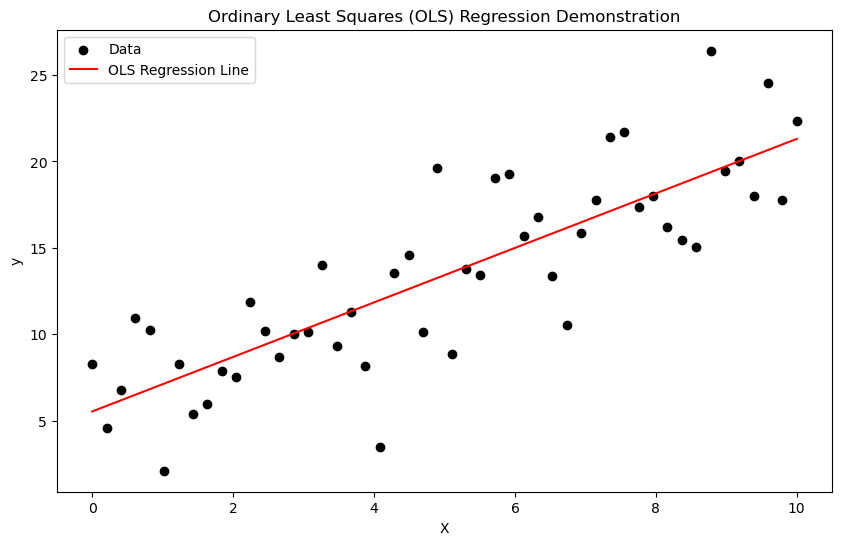

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.680
Method:                 Least Squares   F-statistic:                     105.1
Date:                Sat, 06 Sep 2025   Prob (F-statistic):           1.12e-13
Time:                        11:07:38   Log-Likelihood:                -128.12
No. Observations:                  50   AIC:                             260.2
Df Residuals:                      48   BIC:                             264.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5391      0.892      6.207      0.0

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Generate synthetic linear data
np.random.seed(0)
X = np.linspace(0, 10, 50)
y = 3 + 2*X + np.random.normal(scale=3, size=X.shape)

# Add constant for intercept
X_with_const = sm.add_constant(X)

# Ordinary Least Squares regression
model = sm.OLS(y, X_with_const)
results = model.fit()

# Predictions
y_pred = results.predict(X_with_const)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Data", color="black")
plt.plot(X, y_pred, label="OLS Regression Line", color="red")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Ordinary Least Squares (OLS) Regression Demonstration")
plt.legend()
plt.show()

# Display regression summary
print(results.summary())


### Interpretation of summary()

* **Dep. Variable: y** → The dependent variable being predicted. Here it’s `y`.
* **R-squared: 0.686** → 68.6% of the variation in `y` is explained by `x1`. Decent explanatory power.
* **Adj. R-squared: 0.680** → Adjusts for number of predictors. Very close to R² since only one predictor. Confirms good fit.
* **Model: OLS** → Ordinary Least Squares regression used.
* **Method: Least Squares** → Coefficients estimated by minimizing sum of squared residuals.
* **F-statistic: 105.1** → Tests whether the model explains significant variation in `y`. Large value means strong relationship.
* **Prob (F-statistic): 1.12e-13** → p-value for F-test. Almost zero. Model is statistically significant.
* **Date / Time** → When the model was run. No analytical impact.
* **Log-Likelihood: -128.12** → Likelihood measure. Closer to 0 is better. Mainly used for comparing models.
* **AIC: 260.2 / BIC: 264.1** → Information criteria. Lower = better. Used when comparing models with different predictors.

---

#### Observations and Degrees of Freedom

* **No. Observations: 50** → Sample size = 50. Larger samples give more reliable estimates.
* **Df Residuals: 48** → Degrees of freedom left after estimating parameters. Formula: $n - k$, where $k$ = number of estimated parameters (here 2: intercept + slope).
* **Df Model: 1** → Number of explanatory variables (only `x1`).
* **Covariance Type: nonrobust** → Default error estimation. Alternatives (robust, clustered) handle heteroscedasticity or dependence.

---

#### Coefficients Table


| Variable | Coefficient | Std. Error | t-Statistic | P-Value | 95% Confidence Interval |
| -------- | ----------- | ---------- | ----------- | ------- | ----------------------- |
| const    | 5.5391      | 0.892      | 6.207       | 0.000   | \[3.745, 7.333]         |
| x1       | 1.5765      | 0.154      | 10.252      | 0.000   | \[1.267, 1.886]         |


* **coef**

  * `const = 5.54` → Predicted $y$ when $x1 = 0$.
  * `x1 = 1.58` → For every 1-unit increase in `x1`, `y` increases by \~1.58 units.
* **std err**

  * Measures uncertainty of coefficient estimate. Smaller = more precise.
* **t**

  * Test statistic for hypothesis $H_0: \beta=0$.
  * Example: $t = 10.25$ for `x1` means the slope is very far from zero.
* **P>|t|**

  * p-value for the t-test. Both are 0.000 → coefficients are statistically significant.
* **\[0.025, 0.975]**

  * 95% confidence interval. For `x1`, true slope lies between 1.27 and 1.89 with 95% confidence.

---

#### Residual Diagnostics

* **Omnibus: 0.236 / Prob(Omnibus): 0.889** → Test for normality of residuals. High p-value = residuals look normal.
* **Jarque-Bera (JB): 0.023 / Prob(JB): 0.989** → Another normality test. p ≈ 0.99 → no evidence against normal distribution.
* **Skew: -0.051** → Residuals are almost symmetric (0 = perfect symmetry).
* **Kurtosis: 3.022** → Residuals have near-normal tail behavior (3 = normal).
* **Durbin-Watson: 2.078** → Tests autocorrelation in residuals. 2 = no autocorrelation. Value here is excellent.
* **Cond. No.: 11.7** → Condition number. Low (< 30) → no multicollinearity problems.

---

#### Impact Summary

* Model is **statistically significant** (F-test p ≈ 0).
* **x1** strongly predicts `y` (slope \~1.58, highly significant).
* Residual diagnostics confirm **assumptions of OLS hold** (normality, independence, no multicollinearity).
* About **69% of variation** in `y` is explained. Remaining 31% is due to noise or omitted variables.



### DIfference between OLS  & Gradient Descent

#### Ordinary Least Squares (OLS)

* **Definition**: A **closed-form analytical solution** to find regression coefficients (β) that minimize the sum of squared residuals (errors).
* **Formula**:

  $$
  \hat{\beta} = (X^TX)^{-1}X^Ty
  $$

  where $X$ = features matrix, $y$ = target vector.
* **Characteristics**:

  * Direct computation, **no iteration**.
  * **Fast** for small datasets with few features.
  * Requires computing the **inverse of $X^TX$**, which can be expensive if the dataset has **very high dimensionality**.
  * Works best when features are not highly correlated (multicollinearity can cause instability).

---

#### Gradient Descent (GD)

* **Definition**: An **iterative optimization algorithm** that minimizes the cost function (e.g., Mean Squared Error) by gradually updating coefficients in the opposite direction of the gradient.
* **Update rule**:

  $$
  \beta_j := \beta_j - \alpha \frac{\partial J(\beta)}{\partial \beta_j}
  $$

  where $\alpha$ = learning rate.
* **Characteristics**:

  * Works even when **closed-form solutions are not feasible** (e.g., large-scale data, complex models).
  * Handles **very high-dimensional data** efficiently since it avoids matrix inversion.
  * Requires choosing hyperparameters (learning rate, iterations).
  * May converge slowly or get stuck in local minima (for non-convex problems).

---

**Key Differences**

| Aspect            | OLS (Closed-form)                       | Gradient Descent (Iterative)                   |
| ----------------- | --------------------------------------- | ---------------------------------------------- |
| **Solution type** | Exact (analytical)                      | Approximate (iterative)                        |
| **Computation**   | Requires matrix inversion $(X^TX)^{-1}$ | Updates step by step using gradients           |
| **Speed**         | Fast for small/medium datasets          | Scales better for huge datasets                |
| **Memory**        | Needs to store large matrices           | Works in batches (mini-batch GD)               |
| **Use case**      | Low-dimensional, small data             | Large-scale, high-dimensional, online learning |

---

**Summary**:

* Use **OLS** when the dataset is small, with few features → quick and exact.
* Use **Gradient Descent** when the dataset is very large or high-dimensional → scalable and flexible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic linear data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# OLS closed-form solution
theta_ols = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Gradient Descent
eta = 0.1
n_iterations = 50
m = len(X_b)
theta = np.random.randn(2, 1)  # random init
theta_path = [theta]

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    theta_path.append(theta)

theta_path = np.array(theta_path)

# Compute cost function grid
theta0_vals = np.linspace(-1, 8, 100)
theta1_vals = np.linspace(1, 5, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([[T0[i, j]], [T1[i, j]]])
        cost[i, j] = np.mean((X_b.dot(t) - y) ** 2)

# ==============================
# Combined subplot figure
# ==============================
fig = plt.figure(figsize=(16, 8))

# --- Subplot 1: Regression line ---
ax1 = fig.add_subplot(231)
ax1.scatter(X, y, alpha=0.6)
ax1.plot(X, X_b.dot(theta_ols), "r-", label="OLS Solution")
ax1.plot(X, X_b.dot(theta), "g--", label="GD Solution (50 iters)")
ax1.set_xlabel("X")
ax1.set_ylabel("y")
ax1.set_title("OLS vs GD (Regression Line)")
ax1.legend()

# --- Subplot 2: Contour cost function ---
ax2 = fig.add_subplot(232)
CS = ax2.contour(T0, T1, cost, levels=np.logspace(-1, 3, 20), cmap="jet")
ax2.plot(theta_path[:, 0], theta_path[:, 1], "yo-", label="GD Path")
ax2.plot(theta_ols[0, 0], theta_ols[1, 0], "r*", markersize=15, label="OLS")
ax2.set_xlabel(r"$\theta_0$")
ax2.set_ylabel(r"$\theta_1$")
ax2.set_title("GD Path on Cost Function Contours")
ax2.legend()

# --- Subplot 3: 3D cost surface ---
ax3 = fig.add_subplot(233, projection="3d")
ax3.plot_surface(T0, T1, cost, cmap="viridis", alpha=0.8)
ax3.plot(theta_path[:, 0], theta_path[:, 1],
         [np.mean((X_b.dot(t.reshape(-1, 1)) - y) ** 2) for t in theta_path],
         "yo-", markersize=5, label="GD Path")
ax3.scatter(theta_ols[0, 0], theta_ols[1, 0],
            np.mean((X_b.dot(theta_ols) - y) ** 2),
            c="red", marker="*", s=200, label="OLS")
ax3.set_xlabel(r"$\theta_0$")
ax3.set_ylabel(r"$\theta_1$")
ax3.set_zlabel("Cost (MSE)")
ax3.set_title("Cost Surface with GD vs OLS")
ax3.legend()

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic linear data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# OLS closed-form solution
theta_ols = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Gradient Descent
eta = 0.1
n_iterations = 50
m = len(X_b)
theta = np.random.randn(2, 1)  # random init
theta_path = [theta]

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    theta_path.append(theta)

theta_path = np.array(theta_path)

# Compute cost function grid
theta0_vals = np.linspace(-1, 8, 100)
theta1_vals = np.linspace(1, 5, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

cost = np.zeros(T0.shape)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([[T0[i, j]], [T1[i, j]]])
        cost[i, j] = np.mean((X_b.dot(t) - y) ** 2)

# 2D Contour Plot

ax4 = fig.add_subplot(234)
ax4.contour(T0, T1, cost, levels=50, cmap="viridis")
contours = plt.contour(T0, T1, cost, levels=50, cmap="viridis")
ax4.clabel(contours, inline=True, fontsize=8)

# Gradient Descent path
ax4.plot(theta_path[:, 0], theta_path[:, 1], "yo-", markersize=5, label="GD Path")

# OLS solution
ax4.scatter(theta_ols[0, 0], theta_ols[1, 0], c="red", marker="*", s=200, label="OLS Solution")

ax4.set_xlabel(r"$\theta_0$")
ax4.set_ylabel(r"$\theta_1$")
ax4.set_title("OLS vs Gradient Descent on Cost Function (2D Contours)")
ax4.legend()


import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic linear data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# OLS closed-form solution
theta_ols = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Gradient Descent
eta = 0.1
n_iterations = 50
m = len(X_b)
theta = np.random.randn(2, 1)  # random init
theta_path = [theta]
cost_values = []

for iteration in range(n_iterations):
    cost = np.mean((X_b.dot(theta) - y) ** 2)
    cost_values.append(cost)
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    theta_path.append(theta)

theta_path = np.array(theta_path)

# Final OLS cost
ols_cost = np.mean((X_b.dot(theta_ols) - y) ** 2)

# Plot Cost vs Iterations (Gradient Descent)
ax5 = fig.add_subplot(235)
ax5.plot(range(len(cost_values)), cost_values, "bo-", label="Gradient Descent Path")
ax5.axhline(y=ols_cost, color="red", linestyle="--", label="OLS Cost (Closed Form)")
ax5.set_xlabel("Iterations")
ax5.set_ylabel("Cost (MSE)")
ax5.set_title("Cost Function Convergence: Gradient Descent vs OLS")
ax5.legend()


# Plot Theta path vs OLS
ax6 = fig.add_subplot(236)
ax6.plot(theta_path[:, 0], theta_path[:, 1], "yo-", markersize=5, label="GD Path (θ0, θ1)")
ax6.scatter(theta_ols[0, 0], theta_ols[1, 0], c="red", marker="*", s=200, label="OLS Solution")
ax6.set_xlabel(r"$\theta_0$")
ax6.set_ylabel(r"$\theta_1$")
ax6.set_title("Theta Path in Gradient Descent vs OLS Solution")
ax6.legend()



plt.tight_layout()
plt.show()
